# 5-2. Self-Corrective Modular RAG

## 실습 주제

`공직자_민원응대_핵심_매뉴얼.pdf` 데이터를 활용하여 **조건 분기와 재시도 루프가 있는 Modular RAG**를 구현한다.

5-1 노트북에서는 다음과 같은 선형 Modular RAG를 구현했다.

```text
START
→ classify_question
→ retrieve_manual
→ organize_evidence
→ generate_answer
→ validate_answer
→ END
```

이번 5-2 노트북에서는 검색 결과와 답변 품질을 평가한 뒤, 부족한 경우 다시 검색하거나 질문을 재작성하는 구조로 확장한다.

```text
사용자 질문
   ↓
Query Rewrite Node
   ↓
Retrieve Node
   ↓
Document Relevance Check Node
   ↓
관련 문서 충분?
   ├─ No → Query Rewrite Node로 재진입
   └─ Yes
        ↓
Evidence Organize Node
        ↓
Generate Answer Node
        ↓
Answer Evaluation Node
        ↓
답변 충분?
   ├─ No → Retrieve Node 또는 Query Rewrite Node
   └─ Yes → 최종 답변
```

## 학습 목표

- LangGraph의 `Conditional Edge`를 RAG 흐름에 적용한다.
- 검색 결과가 부족할 때 질문을 다시 작성하는 루프를 구현한다.
- 답변이 부족할 때 재검색 또는 재작성으로 흐름을 되돌린다.
- 단순 RAG와 Self-Corrective Modular RAG의 차이를 이해한다.


## 0. 실습 전제

- 데이터 파일: `../data/공직자_민원응대_핵심_매뉴얼.pdf`
- LLM: `gpt-4o-mini`
- Embedding: `text-embedding-3-small`
- Vector DB: Qdrant 인메모리 모드
- 목표: 공직자 민원응대 매뉴얼 기반 질의응답 시스템 구현

> 이 노트북은 12번 실습 다음 단계로 사용할 수 있도록, `src` 파일 없이 노트북 안에서 전체 흐름을 구현한다.


In [1]:
from typing import Literal
from typing_extensions import TypedDict, NotRequired

from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../../.env")

MAX_REWRITE_COUNT = 3
MAX_ANSWER_RETRY = 2

## 1. 벡터스토어 객체 생성


In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from const.const import create_model, create_embedding

QDRANT_URL = "http://localhost:6333"
COLLECTION_NAME = "civil_complaint_manual_medium"

EMBEDDING_MODEL = "text-embedding-3-small"

embeddings = create_embedding()

vector_store = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    url=QDRANT_URL,
)

/Users/parkchanryong/Desktop/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:250: UserWarning: Found nvidia/nemotron-3-embed-1b in available_models, but type is unknown and inference may fail.
  warnings.warn(


## 2. LLM 및 프롬프트 구성

이번 실습에서는 세 가지 판단/생성 프롬프트를 사용한다.

| 프롬프트                 | 역할                                        |
| ------------------------ | ------------------------------------------- |
| Query Rewrite Prompt     | 질문을 검색에 적합한 질의로 재작성          |
| Document Grade Prompt    | 검색된 문서가 질문에 답하기 충분한지 판단   |
| Answer Evaluation Prompt | 생성된 답변이 근거에 기반하고 충분한지 판단 |


In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = create_model()


query_rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
당신은 공직자 민원응대 매뉴얼 검색 질의 생성기입니다.

역할:
- 사용자의 질문을 매뉴얼 검색에 적합한 질의로 바꿉니다.
- 민원응대 상황, 대응 절차, 보호조치, 법적 조치, 기록, 보고와 관련된 핵심어를 포함합니다.
- 너무 긴 문장보다 검색에 유리한 명사구 중심으로 작성합니다.

출력:
- 검색 질의만 한 줄로 출력하세요.
""",
        ),
        (
            "human",
            """
원 질문:
{question}

이전 검색 질의:
{previous_query}

이전 평가 결과:
{grade}

재작성 횟수:
{rewrite_count}
""",
        ),
    ]
)


document_grade_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
당신은 RAG 검색 결과 평가자입니다.

검색된 문단이 사용자의 질문에 답하기 충분한지 판단하세요.

판단 기준:
- 질문의 핵심 상황과 직접 관련된 내용이 있는가?
- 대응 절차나 조치가 포함되어 있는가?
- 매뉴얼 근거로 답변을 만들 수 있는가?

출력 형식:
- 반드시 "충분:" 또는 "부족:"으로 시작하세요.
- 그 뒤에 한 문장으로 이유를 쓰세요.
""",
        ),
        (
            "human",
            """
질문:
{question}

검색 질의:
{rewritten_query}

검색 문단:
{context}
""",
        ),
    ]
)


evidence_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
검색된 문단에서 질문 답변에 필요한 핵심 근거만 정리하세요.
문단에 없는 내용은 추가하지 마세요.
근거가 부족하면 부족하다고 명시하세요.
""",
        ),
        (
            "human",
            """
질문:
{question}

검색 문단:
{context}
""",
        ),
    ]
)


answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
당신은 공직자 민원응대 매뉴얼 기반 업무지원 AI입니다.

규칙:
- 반드시 제공된 근거에 기반하여 답변하세요.
- 매뉴얼에 없는 내용은 추측하지 마세요.
- 민원응대 담당자가 현장에서 바로 참고할 수 있게 작성하세요.
- 위험 상황에서는 안전 확보, 보고, 기록, 보호조치를 우선합니다.

답변 형식:
1. 상황 판단
2. 즉시 대응
3. 단계별 조치
4. 민원인에게 사용할 수 있는 안내 표현
5. 담당자 보호조치
6. 주의사항
""",
        ),
        (
            "human",
            """
질문:
{question}

근거:
{evidence}
""",
        ),
    ]
)


answer_evaluation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
당신은 RAG 답변 검토자입니다.

답변이 다음 조건을 충족하는지 평가하세요.
- 질문에 직접 답하는가?
- 검색 근거에 기반하는가?
- 대응 절차가 충분히 구체적인가?
- 매뉴얼에 없는 내용을 추측하지 않았는가?

출력 형식:
- 반드시 "충분:", "부분충분:", "부족:" 중 하나로 시작하세요.
- 그 뒤에 한 문장으로 이유를 쓰세요.
""",
        ),
        (
            "human",
            """
질문:
{question}

검색 근거:
{context}

답변:
{answer}
""",
        ),
    ]
)


query_rewrite_chain = query_rewrite_prompt | llm | StrOutputParser()
document_grade_chain = document_grade_prompt | llm | StrOutputParser()
evidence_chain = evidence_prompt | llm | StrOutputParser()
answer_chain = answer_prompt | llm | StrOutputParser()
answer_evaluation_chain = answer_evaluation_prompt | llm | StrOutputParser()

/Users/parkchanryong/Desktop/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:250: UserWarning: Found z-ai/glm-5.3-flash in available_models, but type is unknown and inference may fail.
  warnings.warn(


## 3. 유틸 함수

검색 문서를 LLM에 전달하기 쉬운 문자열로 변환한다.


In [4]:
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END


def format_docs(docs: list[Document]) -> str:
    formatted = []

    for i, doc in enumerate(docs, start=1):
        formatted.append(
            f"[근거 {i}] page={doc.metadata.get('page')}, chunk={doc.metadata.get('chunk_id')}\n"
            f"{doc.page_content}"
        )

    return "\n\n".join(formatted)


def starts_with_sufficient(text: str) -> bool:
    return text.strip().startswith("충분")


def starts_with_insufficient(text: str) -> bool:
    return text.strip().startswith("부족")

## 4. State 정의

이번 실습에서는 루프 제어를 위해 `rewrite_count`, `answer_retry_count`를 추가한다.

| State 항목         | 의미                             |
| ------------------ | -------------------------------- |
| question           | 원 질문                          |
| rewritten_query    | 재작성된 검색 질의               |
| documents          | 검색된 문서                      |
| context            | 검색 문서를 문자열로 정리한 내용 |
| document_grade     | 검색 문서 충분성 평가 결과       |
| evidence           | 답변 생성에 사용할 핵심 근거     |
| answer             | 생성 답변                        |
| answer_grade       | 답변 품질 평가 결과              |
| rewrite_count      | 질문 재작성 횟수                 |
| answer_retry_count | 답변 재시도 횟수                 |


In [5]:
class SelfCorrectiveRAGState(TypedDict):
    question: str
    rewritten_query: NotRequired[str]
    previous_query: NotRequired[str]
    documents: NotRequired[list[Document]]
    context: NotRequired[str]
    document_grade: NotRequired[str]
    evidence: NotRequired[str]
    answer: NotRequired[str]
    answer_grade: NotRequired[str]
    rewrite_count: NotRequired[int]
    answer_retry_count: NotRequired[int]

## 5. Node 정의

각 노드는 하나의 역할만 수행한다.

```text
query_rewrite_node
retrieve_manual_node
grade_documents_node
organize_evidence_node
generate_answer_node
evaluate_answer_node
```


In [6]:
# ── 노드 1: Query Rewrite ────────────────────────────
def query_rewrite_node(state: SelfCorrectiveRAGState) -> dict:
    rewrite_count = state.get("rewrite_count", 0)
    previous_query = state.get("rewritten_query", "")

    rewritten_query = query_rewrite_chain.invoke(
        {
            "question": state["question"],
            "previous_query": previous_query,
            "grade": state.get("document_grade", ""),
            "rewrite_count": rewrite_count,
        }
    ).strip()

    print(f"\n[Query Rewrite] rewrite_count={rewrite_count + 1}")
    print(rewritten_query)

    return {
        "previous_query": previous_query,
        "rewritten_query": rewritten_query,
        "rewrite_count": rewrite_count + 1,
    }


# ── 노드 2: 매뉴얼 검색 ──────────────────────────────
def retrieve_manual_node(state: SelfCorrectiveRAGState) -> dict:
    query = state.get("rewritten_query") or state["question"]

    # 재시도할수록 조금 더 많은 문서를 검색한다.
    answer_retry_count = state.get("answer_retry_count", 0)
    top_k = min(6, 4 + answer_retry_count)

    docs = vector_store.similarity_search(query, k=top_k)
    context = format_docs(docs)

    print(f"\n[Retrieve] top_k={top_k}")
    for doc in docs:
        print(
            f"- page={doc.metadata.get('page')}, chunk={doc.metadata.get('chunk_id')}"
        )

    return {
        "documents": docs,
        "context": context,
    }


# ── 노드 3: 문서 평가 ─────────────────────────────────
def grade_documents_node(state: SelfCorrectiveRAGState) -> dict:
    grade = document_grade_chain.invoke(
        {
            "question": state["question"],
            "rewritten_query": state["rewritten_query"],
            "context": state["context"],
        }
    ).strip()

    print("\n[Document Grade]")
    print(grade)

    return {
        "document_grade": grade,
    }


# ── 노드 4: 근거 정리 ─────────────────────────────────
def organize_evidence_node(state: SelfCorrectiveRAGState) -> dict:
    evidence = evidence_chain.invoke(
        {
            "question": state["question"],
            "context": state["context"],
        }
    ).strip()

    print("\n[Evidence Organized]")
    print(evidence[:500])

    return {
        "evidence": evidence,
    }


# ── 노드 5: 답변 생성 ─────────────────────────────────
def generate_answer_node(state: SelfCorrectiveRAGState) -> dict:
    answer = answer_chain.invoke(
        {
            "question": state["question"],
            "evidence": state["evidence"],
        }
    ).strip()

    print("\n[Generate Answer]")
    print(answer[:500])

    return {
        "answer": answer,
    }


# ── 노드 6: 답변 평가 ─────────────────────────────────
def evaluate_answer_node(state: SelfCorrectiveRAGState) -> dict:
    answer_retry_count = state.get("answer_retry_count", 0)

    grade = answer_evaluation_chain.invoke(
        {
            "question": state["question"],
            "context": state["context"],
            "answer": state["answer"],
        }
    ).strip()

    print("\n[Answer Evaluation]")
    print(grade)

    return {
        "answer_grade": grade,
        "answer_retry_count": answer_retry_count + 1,
    }

## 6. Conditional Edge 함수 정의

검색 문서가 부족하면 `query_rewrite`로 되돌아간다.  
답변이 부족하면 재작성 또는 재검색으로 되돌아간다.


In [7]:
def starts_with_sufficient(text: str) -> bool:
    return text.strip().startswith("충분")


def route_after_document_grade(
    state: SelfCorrectiveRAGState,
) -> Literal["organize_evidence", "query_rewrite"]:
    grade = state.get("document_grade", "")
    rewrite_count = state.get("rewrite_count", 0)

    if starts_with_sufficient(grade):
        print("[Route] 문서 충분 → 근거 정리")
        return "organize_evidence"

    if rewrite_count < MAX_REWRITE_COUNT:
        print("[Route] 문서 부족 → 질문 재작성")
        return "query_rewrite"

    # 재작성 한도 도달 → 현재 문서로 최선의 답변 생성
    print("[Route] 재작성 한도 도달 → 현재 문서로 답변 생성")
    return "organize_evidence"


def route_after_answer_evaluation(
    state: SelfCorrectiveRAGState,
) -> Literal["end", "query_rewrite", "retrieve_manual"]:
    answer_grade = state.get("answer_grade", "")
    rewrite_count = state.get("rewrite_count", 0)
    answer_retry_count = state.get("answer_retry_count", 0)

    if starts_with_sufficient(answer_grade):
        print("\n[Route] 답변 충분 → 종료")
        return "end"

    if answer_retry_count >= MAX_ANSWER_RETRY:
        print("\n[Route] 답변 재시도 한도 도달 → 종료")
        return "end"

    if rewrite_count < MAX_REWRITE_COUNT:
        print("\n[Route] 답변 부족 → 질문 재작성")
        return "query_rewrite"

    print("\n[Route] 답변 부족 → 검색 문서 확대")
    return "retrieve_manual"

## 7. Graph 구성

`add_conditional_edges()`를 사용하여 검색 평가와 답변 평가 이후의 흐름을 동적으로 결정한다.


In [8]:
graph = StateGraph(SelfCorrectiveRAGState)

graph.add_node("query_rewrite", query_rewrite_node)
graph.add_node("retrieve_manual", retrieve_manual_node)
graph.add_node("grade_documents", grade_documents_node)
graph.add_node("organize_evidence", organize_evidence_node)
graph.add_node("generate_answer", generate_answer_node)
graph.add_node("evaluate_answer", evaluate_answer_node)

graph.add_edge(START, "query_rewrite")
graph.add_edge("query_rewrite", "retrieve_manual")
graph.add_edge("retrieve_manual", "grade_documents")

graph.add_conditional_edges(
    "grade_documents",
    route_after_document_grade,
    {
        "organize_evidence": "organize_evidence",
        "query_rewrite": "query_rewrite",
    },
)

graph.add_edge("organize_evidence", "generate_answer")
graph.add_edge("generate_answer", "evaluate_answer")

graph.add_conditional_edges(
    "evaluate_answer",
    route_after_answer_evaluation,
    {
        "end": END,
        "query_rewrite": "query_rewrite",
        "retrieve_manual": "retrieve_manual",
    },
)

app = graph.compile()

## 8. 그래프 시각화

그래프를 시각화하면 이번 실습의 핵심인 루프 구조를 확인할 수 있다.


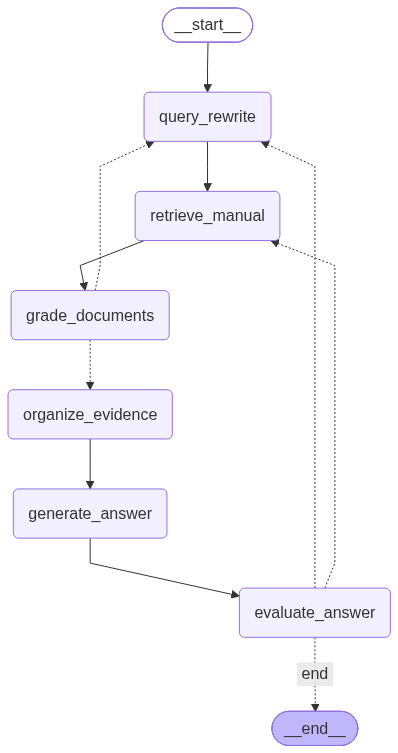

In [9]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

| 단계 | 노드                | 핵심 의미                   |
| ---: | ------------------- | --------------------------- |
|    1 | `query_rewrite`     | 질문을 검색 친화적으로 바꿈 |
|    2 | `retrieve_manual`   | 매뉴얼에서 관련 문서 검색   |
|    3 | `grade_documents`   | 검색 문서가 충분한지 판단   |
|    4 | `organize_evidence` | 답변에 사용할 근거 정리     |
|    5 | `generate_answer`   | 근거 기반 답변 생성         |
|    6 | `evaluate_answer`   | 답변 품질 평가              |
|    7 | `end`               | 충분한 답변이면 종료        |


## 9. 실행 예제 1: 대면 폭행 민원 대응

폭행, 대면 민원, 안전 확보, 보고, 기록, 보호조치 등이 검색되어야 한다.


In [10]:
question = "대면 민원 중 민원인이 직원을 폭행하면 현장에서 어떻게 대응해야 하나요?"

result = app.invoke(
    {
        "question": question,
        "rewrite_count": 0,
        "answer_retry_count": 0,
    }
)

print("\n" + "=" * 80)
print("[최종 검색 질의]")
print(result.get("rewritten_query"))

print("\n[문서 평가]")
print(result.get("document_grade"))

print("\n[최종 답변]")
print(result.get("answer"))

print("\n[답변 평가]")
print(result.get("answer_grade"))


[Query Rewrite] rewrite_count=1
대면 민원인 폭행 현장 대응 절차 직원 보호조치 경찰 신고 법적 조치

[Retrieve] top_k=4
- page=8, chunk=12
- page=8, chunk=13
- page=8, chunk=11
- page=3, chunk=2

[Document Grade]
충분: 검색 결과에 폭행 발생 시 즉시 도움 요청·담당자 분리조치·녹화·안전요원 호출 및 경찰 신고 등 현장 대응 절차와, 피해직원 보호조치(면담, 휴게시간, 공무상 병가, 심리상담 등), 법적 조치(형법 제136조 공무집행방해죄 근거 경고, 고소·고발 협의) 및 위법행위 관리대장 작성까지 매뉴얼 근거로 상세히 포함되어 있습니다.
[Route] 문서 충분 → 근거 정리

[Evidence Organized]


[Generate Answer]
# 대면 민원 중 폭행 사태 대응

> ⚠️ **참고**: 이 질문에는 매뉴얼 근거가 제공되지 않았습니다. 아래 내용은 민원응대 원칙상 우선시되는 항목(안전 확보 → 보고 → 기록 → 보호조치)을 기반으로 한 일반 대응 지침이며, 소속 기관의 실제 매뉴얼·규정과 반드시 대조하여 확인하십시오.

---

## 1. 상황 판단
- 폭행은 단순한 민원 불만이 아니라 **범죄 행위이자 즉각적 위험 상황**입니다.
- 이 시점부터는 "민원 응대"가 아니라 **안전 확보 및 초동수 조치**가 최우선입니다.
- 다음 여부를 신속히 판단합니다:
  - 직원의 부상 여부
  - 가해자가 추가 폭력을 행사할 위험 여부
  - 주변에 도움을 요청할 수 있는 인력(동료, 경비, 경찰)의 유무

## 2. 즉시 대응
1. **안전 확보**: 가해자와의 물리적 거리를 확보하고, 가능하면 안전한 공간(별도실, 사무실 내부 등)으로 대피합니다. 폭행에 맞서거나 제지하려다 2차 피해가 발생하지 않도록 합니다.
2

[Answer Evaluation]


[Route] 답변 부족 → 질문 재작성

[Query Rewrite] r

## 10. 실행 예제 2: 반복 전화 민원 대응

반복 전화, 장시간 통화, 통화 종료 안내, 녹음, 상급자 보고 등 관련 근거를 검색하는지 확인한다.


In [11]:
question = "같은 민원인이 계속 전화해서 같은 말을 반복하면 담당자는 어떻게 해야 하나요?"

result = app.invoke(
    {
        "question": question,
        "rewrite_count": 0,
        "answer_retry_count": 0,
    }
)

print("\n" + "=" * 80)
print("[최종 검색 질의]")
print(result.get("rewritten_query"))

print("\n[문서 평가]")
print(result.get("document_grade"))

print("\n[최종 답변]")
print(result.get("answer"))

print("\n[답변 평가]")
print(result.get("answer_grade"))


[Query Rewrite] rewrite_count=1
동일 민원인 반복 전화 응대 절차 및 과잉민원 처리 방법

[Retrieve] top_k=4
- page=6, chunk=7
- page=10, chunk=17
- page=3, chunk=2
- page=13, chunk=23


Exception: [504] Gateway Timeout
{'_content': b'', '_content_consumed': True, '_next': None, 'status_code': 504, 'headers': {'date': 'Mon, 28 Sep 2026 07:55:28 GMT', 'content-length': '0', 'access-control-expose-headers': 'nvcf-reqid', 'nvcf-reqid': '52ceff18-d8ce-465e-911e-dd78cb80db16', 'nvcf-status': 'errored', 'vary': 'Origin'}, 'raw': <urllib3.response.HTTPResponse object at 0x118e38220>, 'url': 'https://integrate.api.nvidia.com/v1/chat/completions', 'encoding': None, 'history': [], 'reason': 'Gateway Timeout', 'cookies': <RequestsCookieJar[]>, 'elapsed': datetime.timedelta(seconds=302, microseconds=335048), 'request': <PreparedRequest [POST]>, 'connection': <requests.adapters.HTTPAdapter object at 0x1190745f0>}

## 11. 실행 예제 3: 모호한 질문

질문이 모호할 때 Query Rewrite가 어떻게 검색 질의를 구체화하는지 확인한다.


In [ ]:
question = "민원인이 너무 심하게 굴면 어떻게 해야 해요?"

result = app.invoke(
    {
        "question": question,
        "rewrite_count": 0,
        "answer_retry_count": 0,
    }
)

print("\n" + "=" * 80)
print("[최종 검색 질의]")
print(result.get("rewritten_query"))

print("\n[문서 평가]")
print(result.get("document_grade"))

print("\n[최종 답변]")
print(result.get("answer"))

print("\n[답변 평가]")
print(result.get("answer_grade"))

## 12. 수강생 실습 과제

아래 과제를 수행하면서 그래프의 흐름이 어떻게 바뀌는지 확인한다.

### 과제 1. 질문 바꿔보기

다음 질문으로 실행하고 검색 질의가 어떻게 재작성되는지 확인한다.

```text
민원인이 욕설을 하면서 전화를 끊지 않으면 어떻게 해야 하나요?
```

```text
민원인이 흉기를 들고 방문하면 담당자는 어떻게 대응해야 하나요?
```

```text
민원 응대 후 담당자가 심리적으로 힘들면 어떤 보호조치를 받을 수 있나요?
```

### 과제 2. 검색 문서 수 조정하기

`retrieve_manual_node()`의 `top_k` 값을 수정하여 결과가 어떻게 달라지는지 확인한다.

```python
top_k = min(6, 4 + answer_retry_count)
```

### 과제 3. 재작성 한도 바꿔보기

`MAX_REWRITE_COUNT` 값을 1, 2, 3으로 바꿔 보면서 루프 횟수가 어떻게 달라지는지 확인한다.

### 과제 4. 평가 기준 강화하기

`document_grade_prompt`와 `answer_evaluation_prompt`의 판단 기준을 더 엄격하게 바꿔 본다.


## 핵심 정리

```text
START
→ query_rewrite
→ retrieve_manual
→ grade_documents
   ├─ 부족 → query_rewrite
   └─ 충분 → organize_evidence
→ generate_answer
→ evaluate_answer
   ├─ 부족 → query_rewrite 또는 retrieve_manual
   └─ 충분 → END
```

이번 실습의 핵심은 다음과 같다.

1. Modular RAG는 각 기능을 독립 노드로 분리한다.
2. Self-Corrective Modular RAG는 검색 결과와 답변 결과를 평가한다.
3. 검색 문서가 부족하면 질문을 다시 작성한다.
4. 답변이 부족하면 재검색하거나 질문 재작성을 수행한다.
5. LangGraph의 `Conditional Edge`를 사용하면 RAG 흐름을 조건에 따라 제어할 수 있다.

12번 실습이 **선형 Modular RAG**라면, 13번 실습은 **루프가 있는 Self-Corrective Modular RAG**이다.
